# Predicción del punto de corte en trayectorias compuestas por dos regímenes mediante inteligencia artificial

## Formulación del problema y objetivos

Sea $d \in \{1,2,3\}$ y sea

$$
X=(x_0,x_1,\dots,x_{99}),
\qquad x_t \in \mathbb{R}^d \;\; \text{para todo } t=0,\dots,99,
$$

una trayectoria de longitud fija igual a $100$, obtenida por concatenación de dos segmentos separados por un único punto de cambio $k$. Se impone la restricción

$$
20 \leq k \leq 80,
$$

con el fin de garantizar que ambos segmentos tengan longitud mínima igual a $20$. En estas condiciones, el changepoint pertenece al conjunto discreto

$$
\mathcal{K}=\{20,21,\dots,80\},
\qquad |\mathcal{K}|=61.
$$

A cada posición admisible se le asocia una etiqueta discreta definida por

$$
y = k-20 \in \{0,1,\dots,60\}.
$$

De este modo, el problema se reformula como una tarea de clasificación multiclase sobre $61$ categorías. El objetivo es construir una aplicación predictiva

$$
f : (\mathbb{R}^d)^{100} \longrightarrow \mathcal{K},
$$

capaz de estimar la localización del punto de cambio a partir de la trayectoria observada, mediante una representación adecuada de la señal y un modelo neuronal sensible a variaciones estructurales en la dinámica temporal.

## Metodología

La metodología seguida en este trabajo se organiza en cuatro etapas. En primer lugar, se genera un conjunto de trayectorias sintéticas en dimensión $d \in \{1,2,3\}$ mediante modelos de difusión anómala implementados en `andi_datasets`. Cada muestra se construye por concatenación de dos segmentos independientes, separados por un único punto de cambio $k \in \mathcal{K}$, donde

$$
\mathcal{K}=\{20,21,\dots,80\}.
$$

Ambos segmentos pueden diferir en el modelo dinámico subyacente, en el valor del exponente anómalo o en ambas magnitudes. Además, se impone continuidad espacial en el punto de unión, con el fin de evitar discontinuidades artificiales en la trayectoria resultante. Aunque la formulación se ha presentado en dimensión general $d \in \{1,2,3\}$, los experimentos desarrollados en este trabajo se han restringido al caso unidimensional, es decir, $d=1$.

En segundo lugar, cada trayectoria

$$
X=(x_0,x_1,\dots,x_{99}),
\qquad x_t \in \mathbb{R}^d,
$$

se transforma en una representación adecuada para el aprendizaje supervisado. En particular, además de la posición, se consideran las diferencias discretas entre observaciones consecutivas y ciertas magnitudes derivadas de dichas diferencias. Este preprocesado permite resaltar cambios locales de dinámica y, al mismo tiempo, reducir efectos asociados a escalas arbitrarias.

En tercer lugar, el problema se aborda mediante un modelo neuronal supervisado. La arquitectura combina operadores convolucionales unidimensionales, orientados a captar regularidades locales en la señal, con un bloque recurrente bidireccional, destinado a integrar dependencias temporales de mayor alcance. La salida del modelo consiste en una distribución de probabilidad sobre las $61$ posiciones admisibles del changepoint.

Por último, el entrenamiento se lleva a cabo minimizando una función de pérdida de entropía cruzada sobre las etiquetas discretas asociadas al punto de cambio. La evaluación del modelo se realiza mediante métricas de clasificación y de error de localización, en particular accuracy, MAE y RMSE, con el propósito de cuantificar tanto la coincidencia exacta entre predicción y referencia como la desviación media entre la posición estimada y la posición real del changepoint.

## Configuración del experimento

En esta sección se definen los parámetros principales que gobiernan el desarrollo del experimento numérico. En particular, se fijan la longitud de la trayectoria, la dimensión espacial considerada, el tamaño del lote, el número de épocas, así como los hiperparámetros asociados al proceso de optimización. Esta etapa resulta esencial para garantizar la reproducibilidad del procedimiento y mantener la coherencia entre la formulación del problema, la generación de datos y el entrenamiento del modelo.

In [1]:
import random
import inspect
from dataclasses import dataclass
from typing import Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from andi_datasets.datasets_theory import datasets_theory

In [2]:
@dataclass
class Config:
    seq_len: int = 100
    min_seg_len: int = 20
    num_classes: int = 61
    dim: int = 1
    batch_size: int = 128
    epochs: int = 20
    lr: float = 1e-3
    weight_decay: float = 1e-4
    conv_channels: int = 64
    hidden_size: int = 128
    dropout: float = 0.2
    train_size: int = 20000
    val_size: int = 4000
    noise_std: float = 0.10
    seed: int = 42
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    model_path: str = "best_cutpoint_model.pt"

CFG = Config()

In [4]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CFG.seed)

## Funciones auxiliares

Las funciones definidas a continuación permiten codificar la posición del changepoint como una etiqueta discreta, normalizar las trayectorias y construir una representación basada en posiciones e incrementos. Estas operaciones facilitan el entrenamiento del modelo y mejoran la calidad de la información suministrada a la red neuronal.

In [5]:
def cut_to_class(cut_index: int, min_seg_len: int = 20) -> int:
    return cut_index - min_seg_len


def class_to_cut(class_index: int, min_seg_len: int = 20) -> int:
    return class_index + min_seg_len


def normalize_trajectory(x: np.ndarray) -> np.ndarray:
    x = x.astype(np.float32)
    x = x - x[0]

    std = x.std()
    if std < 1e-8:
        std = 1.0

    return x / std


def build_features(x: np.ndarray) -> np.ndarray:
    dx = np.diff(x, prepend=x[0]).astype(np.float32)

    dx_std = dx.std()
    if dx_std < 1e-8:
        dx_std = 1.0

    dx_norm = dx / dx_std
    abs_dx = np.abs(dx_norm)

    features = np.stack([x, dx_norm, abs_dx], axis=-1)
    return features.astype(np.float32)

## Generación de trayectorias con `andi_datasets`

La generación del conjunto de datos sintético se apoya en la librería `andi_datasets`, diseñada para simular trayectorias asociadas a distintos modelos de difusión anómala. En este trabajo, cada segmento se genera de manera independiente a partir de uno de los modelos disponibles, seleccionando además un valor del exponente anómalo compatible con la dinámica considerada.

Con el fin de integrar esta generación dentro del pipeline de entrenamiento, se define una clase auxiliar encargada de dos tareas principales: por una parte, muestrear pares modelo-exponente adecuados; por otra, adaptar la salida de `andi_datasets` a un formato homogéneo y utilizable por el resto del procedimiento. Esta última adaptación resulta especialmente importante, ya que la estructura exacta de la salida puede variar según la versión de la librería instalada.

In [6]:
dt = datasets_theory()

In [7]:
class AndiGenerator:
    def __init__(self, dim: int = 1):
        self.dim = dim
        self.dt = datasets_theory()

        self.model_to_id = {
            "attm": 0,
            "ctrw": 1,
            "fbm": 2,
            "lw": 3,
            "sbm": 4,
        }

        self.models = list(self.model_to_id.keys())

    def sample_model_and_alpha(self) -> Tuple[str, float]:
        model = random.choice(self.models)

        if model in ["attm", "ctrw"]:
            alpha = np.random.uniform(0.05, 1.0)
        elif model == "lw":
            alpha = np.random.uniform(1.0, 2.0)
        elif model == "fbm":
            alpha = np.random.uniform(0.05, 1.95)
        elif model == "sbm":
            alpha = np.random.uniform(0.05, 2.0)
        else:
            raise ValueError(f"Modelo no reconocido: {model}")

        return model, float(alpha)

    def generate_single_segment(self, length: int, model_name: str, alpha: float) -> np.ndarray:
        model_id = self.model_to_id[model_name]

        candidate_kwargs = {
            "T": length,
            "N_models": 1,
            "exponents": [alpha],
            "models": [model_id],
            "dimension": self.dim,
            "N": 1,
        }

        sig = inspect.signature(self.dt.create_dataset)
        valid_kwargs = {
            k: v for k, v in candidate_kwargs.items()
            if k in sig.parameters
        }

        out = self.dt.create_dataset(**valid_kwargs)

        if isinstance(out, tuple):
            trajs = out[0]
        else:
            trajs = out

        trajs = np.asarray(trajs)

        # Caso 1: [N, T, dim]
        if trajs.ndim == 3:
            x = trajs[0, :, 0]

        # Caso 2: [1, T] o [1, T + extra]
        elif trajs.ndim == 2:
            row = trajs[0]

            if row.shape[0] == length:
                x = row
            elif row.shape[0] > length:
                x = row[-length:]
            else:
                raise ValueError(f"No se pudo interpretar la forma {trajs.shape}")

        # Caso 3: [T] o [T + extra]
        elif trajs.ndim == 1:
            if trajs.shape[0] == length:
                x = trajs
            elif trajs.shape[0] > length:
                x = trajs[-length:]
            else:
                raise ValueError(f"No se pudo interpretar la forma {trajs.shape}")

        else:
            raise ValueError(f"Forma inesperada de salida: {trajs.shape}")

        return np.asarray(x, dtype=np.float32)

## Verificación preliminar del generador

Antes de proceder a la construcción del conjunto de datos completo, resulta conveniente comprobar que el generador de trayectorias funciona de manera correcta y que la salida producida por `andi_datasets` puede integrarse sin ambigüedad en el entorno de trabajo. Esta verificación preliminar permite detectar de forma temprana posibles incompatibilidades asociadas a la estructura de la trayectoria generada o a la versión instalada de la librería.

In [8]:
generator = AndiGenerator(dim=CFG.dim)

model_name, alpha = generator.sample_model_and_alpha()
print("Modelo:", model_name)
print("Alpha:", alpha)

try:
    x_test = generator.generate_single_segment(30, model_name, alpha)
    print("Shape:", x_test.shape)
    print("Primeros valores:", x_test[:5])
except Exception as e:
    print("Error:", e)

Modelo: attm
Alpha: 0.40581311290499433
Shape: (30,)
Primeros valores: [0.        1.7348044 2.7007115 2.669491  2.7055717]


## Construcción del conjunto de datos

El conjunto de datos se construye a partir de trayectorias sintéticas formadas por la concatenación de dos segmentos separados por un único punto de cambio. Para cada muestra, se selecciona una posición admisible del changepoint, se generan de manera independiente los dos segmentos correspondientes y se impone continuidad espacial en el punto de unión. Posteriormente, se añade ruido observacional, se normaliza la trayectoria y se transforma la señal en una representación adecuada para el aprendizaje supervisado.

Con el fin de encapsular este procedimiento de forma sistemática, se define una clase específica que hereda de `Dataset`. Dicha clase permite generar muestras etiquetadas de manera consistente con la formulación del problema y proporciona directamente las entradas y salidas requeridas durante el entrenamiento del modelo.

In [9]:
class AndiCutPointDataset(Dataset):
    def __init__(
        self,
        n_samples: int,
        seq_len: int = 100,
        min_seg_len: int = 20,
        dim: int = 1,
        noise_std: float = 0.10,
        seed: int = 42,
    ):
        self.n_samples = n_samples
        self.seq_len = seq_len
        self.min_seg_len = min_seg_len
        self.dim = dim
        self.noise_std = noise_std
        self.valid_cuts = list(range(min_seg_len, seq_len - min_seg_len + 1))
        self.generator = AndiGenerator(dim=dim)

        set_seed(seed)

    def __len__(self) -> int:
        return self.n_samples

    def __getitem__(self, idx):
        cut = random.choice(self.valid_cuts)

        left_len = cut
        right_len = self.seq_len - cut

        model_left, alpha_left = self.generator.sample_model_and_alpha()
        model_right, alpha_right = self.generator.sample_model_and_alpha()

        while model_left == model_right and abs(alpha_left - alpha_right) < 0.15:
            model_right, alpha_right = self.generator.sample_model_and_alpha()

        x_left = self.generator.generate_single_segment(left_len, model_left, alpha_left)
        x_right = self.generator.generate_single_segment(right_len, model_right, alpha_right)

        x_right = x_right - x_right[0] + x_left[-1]
        x = np.concatenate([x_left, x_right], axis=0)

        noise = np.random.normal(0.0, self.noise_std, size=x.shape)
        x = x + noise

        x = normalize_trajectory(x)
        feats = build_features(x)

        y_cls = cut_to_class(cut, self.min_seg_len)

        return (
            torch.tensor(feats, dtype=torch.float32),
            torch.tensor(y_cls, dtype=torch.long),
            torch.tensor(cut, dtype=torch.long),
        )

## Verificación básica del conjunto de datos

Una vez definida la clase anterior, se realiza una comprobación elemental sobre una muestra concreta del dataset. Esta verificación permite confirmar que la trayectoria generada presenta la forma esperada, que la codificación de la clase es consistente con la posición real del changepoint y que la salida puede integrarse correctamente en el pipeline de entrenamiento.

In [10]:
train_dataset = AndiCutPointDataset(
    n_samples=100,
    seq_len=CFG.seq_len,
    min_seg_len=CFG.min_seg_len,
    dim=CFG.dim,
    noise_std=CFG.noise_std,
    seed=CFG.seed,
)

x_sample, y_cls_sample, y_cut_sample = train_dataset[0]

print("Forma de x:", x_sample.shape)
print("Clase:", y_cls_sample.item())
print("Corte real:", y_cut_sample.item())

Forma de x: torch.Size([100, 3])
Clase: 40
Corte real: 60


## Arquitectura del modelo

La arquitectura propuesta combina dos mecanismos complementarios para el análisis de trayectorias con cambio de régimen. En una primera etapa, se emplea un bloque convolucional unidimensional encargado de extraer patrones locales a partir de la señal de entrada y de sus variables derivadas. Este bloque permite identificar regularidades de corta escala, tales como variaciones en la intensidad del movimiento, cambios en la estructura de los incrementos o alteraciones locales en la dinámica de la trayectoria.

A continuación, la representación producida por el bloque convolucional se procesa mediante una unidad recurrente bidireccional de tipo GRU. Este componente permite integrar información temporal de mayor alcance y comparar, de manera implícita, el comportamiento observado antes y después de cada posible punto de cambio. Finalmente, la red incorpora un clasificador denso cuya salida está formada por 61 neuronas, una por cada posición admisible del changepoint. De este modo, el modelo produce una distribución de probabilidad sobre el conjunto de localizaciones posibles del punto de corte.

In [13]:
class CutPointNet(nn.Module):
    def __init__(
        self,
        in_channels: int = 3,
        conv_channels: int = 64,
        hidden_size: int = 128,
        num_classes: int = 61,
        dropout: float = 0.2,
    ):
        super().__init__()

        self.conv1 = nn.Conv1d(in_channels, conv_channels, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm1d(conv_channels)

        self.conv2 = nn.Conv1d(conv_channels, conv_channels, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(conv_channels)

        self.conv3 = nn.Conv1d(conv_channels, conv_channels, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(conv_channels)

        self.bigru = nn.GRU(
            input_size=conv_channels,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )

        self.dropout = nn.Dropout(dropout)

        self.classifier = nn.Sequential(
            nn.Linear(2 * hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.transpose(1, 2)

        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))

        x = x.transpose(1, 2)
        h, _ = self.bigru(x)

        h = h.mean(dim=1)
        h = self.dropout(h)

        logits = self.classifier(h)
        return logits

## Métricas de evaluación

La evaluación del modelo se realiza mediante tres métricas: accuracy, MAE y RMSE. La accuracy mide la coincidencia exacta entre la posición predicha y la posición real del changepoint. Por su parte, el MAE cuantifica el error medio absoluto de localización, mientras que el RMSE introduce una penalización mayor sobre las desviaciones más grandes. En conjunto, estas métricas permiten analizar tanto la precisión exacta de la clasificación como la calidad de la estimación desde el punto de vista de la localización.

In [14]:
@torch.no_grad()
def compute_metrics(logits: torch.Tensor, y_cls: torch.Tensor, min_seg_len: int = 20):
    pred_cls = logits.argmax(dim=1)

    pred_cut = pred_cls + min_seg_len
    true_cut = y_cls + min_seg_len

    acc = (pred_cls == y_cls).float().mean().item()
    mae = (pred_cut - true_cut).abs().float().mean().item()
    rmse = torch.sqrt(((pred_cut - true_cut).float() ** 2).mean()).item()

    return {
        "acc": acc,
        "mae": mae,
        "rmse": rmse,
    }

## Entrenamiento y validación

El ajuste del modelo se formula como un problema de aprendizaje supervisado sobre un espacio discreto de 61 clases, cada una de ellas asociada a una posición admisible del changepoint. La optimización se lleva a cabo mediante la minimización de la entropía cruzada multiclase, adecuada en este contexto por la naturaleza categórica de la variable objetivo.

Al término de cada época se evalúa el comportamiento del modelo sobre un conjunto de validación independiente, con el fin de analizar su capacidad de generalización y evitar interpretaciones basadas exclusivamente en el rendimiento observado sobre los datos de entrenamiento. Como criterio de selección del mejor modelo se adopta el menor valor del error absoluto medio (MAE) en validación, al tratarse de una magnitud directamente interpretable en términos de distancia entre la posición predicha y la posición real del punto de cambio.

In [15]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()

    total_loss = 0.0
    total_acc = 0.0
    total_mae = 0.0
    total_rmse = 0.0
    n_batches = 0

    for x, y_cls, _ in loader:
        x = x.to(device)
        y_cls = y_cls.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = F.cross_entropy(logits, y_cls)

        loss.backward()
        optimizer.step()

        metrics = compute_metrics(logits.detach(), y_cls, min_seg_len=CFG.min_seg_len)

        total_loss += loss.item()
        total_acc += metrics["acc"]
        total_mae += metrics["mae"]
        total_rmse += metrics["rmse"]
        n_batches += 1

    return {
        "loss": total_loss / n_batches,
        "acc": total_acc / n_batches,
        "mae": total_mae / n_batches,
        "rmse": total_rmse / n_batches,
    }


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()

    total_loss = 0.0
    total_acc = 0.0
    total_mae = 0.0
    total_rmse = 0.0
    n_batches = 0

    for x, y_cls, _ in loader:
        x = x.to(device)
        y_cls = y_cls.to(device)

        logits = model(x)
        loss = F.cross_entropy(logits, y_cls)

        metrics = compute_metrics(logits, y_cls, min_seg_len=CFG.min_seg_len)

        total_loss += loss.item()
        total_acc += metrics["acc"]
        total_mae += metrics["mae"]
        total_rmse += metrics["rmse"]
        n_batches += 1

    return {
        "loss": total_loss / n_batches,
        "acc": total_acc / n_batches,
        "mae": total_mae / n_batches,
        "rmse": total_rmse / n_batches,
    }

## Inicialización de los conjuntos de datos y del modelo

Una vez definidas las funciones de entrenamiento y validación, se construyen los conjuntos de datos correspondientes, junto con sus respectivos `DataLoader`. A continuación, se inicializa la arquitectura neuronal y se define el optimizador empleado durante el ajuste de los parámetros del modelo.

In [16]:
train_dataset = AndiCutPointDataset(
    n_samples=CFG.train_size,
    seq_len=CFG.seq_len,
    min_seg_len=CFG.min_seg_len,
    dim=CFG.dim,
    noise_std=CFG.noise_std,
    seed=CFG.seed,
)

val_dataset = AndiCutPointDataset(
    n_samples=CFG.val_size,
    seq_len=CFG.seq_len,
    min_seg_len=CFG.min_seg_len,
    dim=CFG.dim,
    noise_std=CFG.noise_std,
    seed=CFG.seed + 1,
)

train_loader = DataLoader(train_dataset, batch_size=CFG.batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=CFG.batch_size, shuffle=False)

model = CutPointNet(
    in_channels=3,
    conv_channels=CFG.conv_channels,
    hidden_size=CFG.hidden_size,
    num_classes=CFG.num_classes,
    dropout=CFG.dropout,
).to(CFG.device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG.lr,
    weight_decay=CFG.weight_decay,
)

## Ejecución del proceso de entrenamiento

Una vez inicializados el modelo, los conjuntos de datos y el optimizador, se ejecuta el procedimiento iterativo de entrenamiento. En cada época se calculan las métricas correspondientes sobre entrenamiento y validación, y se conserva la configuración de parámetros que produce el menor valor de MAE sobre el conjunto de validación.

In [31]:
best_val_mae = float("inf")

for epoch in range(1, CFG.epochs + 1):
    train_metrics = train_one_epoch(model, train_loader, optimizer, CFG.device)
    val_metrics = evaluate(model, val_loader, CFG.device)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_metrics['loss']:.4f} | "
        f"train_acc={train_metrics['acc']:.4f} | "
        f"train_mae={train_metrics['mae']:.2f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_acc={val_metrics['acc']:.4f} | "
        f"val_mae={val_metrics['mae']:.2f} | "
        f"val_rmse={val_metrics['rmse']:.2f}"
    )

    if val_metrics["mae"] < best_val_mae:
        best_val_mae = val_metrics["mae"]
        torch.save(model.state_dict(), CFG.model_path)

print("\nMejor modelo guardado en:", CFG.model_path)
print("Mejor MAE de validación:", best_val_mae)

Epoch 01 | train_loss=4.0761 | train_acc=0.0202 | train_mae=20.69 | val_loss=3.9594 | val_acc=0.0249 | val_mae=17.61 | val_rmse=23.52
Epoch 02 | train_loss=3.8953 | train_acc=0.0360 | train_mae=15.05 | val_loss=3.7517 | val_acc=0.0540 | val_mae=13.02 | val_rmse=18.81
Epoch 03 | train_loss=3.6851 | train_acc=0.0529 | train_mae=11.28 | val_loss=3.5430 | val_acc=0.0742 | val_mae=10.09 | val_rmse=15.80
Epoch 04 | train_loss=3.5242 | train_acc=0.0651 | train_mae=9.64 | val_loss=3.4298 | val_acc=0.0735 | val_mae=9.01 | val_rmse=14.51
Epoch 05 | train_loss=3.4195 | train_acc=0.0730 | train_mae=8.75 | val_loss=3.3123 | val_acc=0.0840 | val_mae=7.82 | val_rmse=12.77
Epoch 06 | train_loss=3.3280 | train_acc=0.0833 | train_mae=8.54 | val_loss=3.2578 | val_acc=0.0967 | val_mae=7.85 | val_rmse=13.07
Epoch 07 | train_loss=3.2444 | train_acc=0.0916 | train_mae=8.42 | val_loss=3.1053 | val_acc=0.1287 | val_mae=7.26 | val_rmse=12.80
Epoch 08 | train_loss=3.1856 | train_acc=0.0983 | train_mae=8.01 | val

## Discusión de resultados

Los resultados obtenidos muestran una evolución consistente del proceso de aprendizaje. En particular, se observa una disminución progresiva de `train_loss`, `val_loss`, `train_mae` y `val_mae`, lo que indica que el modelo aprende una representación progresivamente más informativa de la trayectoria y mejora de forma sostenida tanto sobre los datos de entrenamiento como sobre el conjunto de validación.

La accuracy también presenta una mejora gradual a lo largo de las épocas. No obstante, su interpretación debe realizarse con cautela, ya que el problema se formula sobre 61 clases posibles y la coincidencia exacta entre la posición predicha y la posición real del changepoint constituye un criterio especialmente estricto.

Desde el punto de vista de la localización, la métrica más representativa es el MAE. El mejor modelo alcanza un MAE de validación de $6.29$, lo que equivale a un error medio de aproximadamente seis posiciones en la estimación del changepoint. En conjunto, estos resultados reflejan un comportamiento estable y una capacidad de generalización razonable dentro de la formulación considerada.

## Análisis gráfico del error de localización

Para complementar las métricas globales obtenidas durante el entrenamiento, se presenta a continuación una representación gráfica del comportamiento del modelo en la tarea de localización del changepoint. El objetivo de esta figura es mostrar no solo el error medio global, sino también su dependencia respecto a la posición real del punto de cambio, la relación entre valores predichos y valores verdaderos, y un ejemplo ilustrativo de inferencia sobre una trayectoria concreta.

In [22]:
best_model = CutPointNet(
    in_channels=3,
    conv_channels=CFG.conv_channels,
    hidden_size=CFG.hidden_size,
    num_classes=CFG.num_classes,
    dropout=CFG.dropout,
).to(CFG.device)

best_model.load_state_dict(torch.load(CFG.model_path, map_location=CFG.device))
best_model.eval()

CutPointNet(
  (conv1): Conv1d(3, 64, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bigru): GRU(64, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=61, bias=True)
  )
)

In [23]:
@torch.no_grad()
def collect_validation_predictions(model, dataset, device):
    model.eval()

    true_cuts = []
    pred_cuts = []
    abs_errors = []
    examples = []

    for i in range(len(dataset)):
        x, y_cls, y_cut = dataset[i]

        logits = model(x.unsqueeze(0).to(device))
        pred_cls = logits.argmax(dim=1).item()
        pred_cut = class_to_cut(pred_cls, min_seg_len=CFG.min_seg_len)

        true_cut = int(y_cut.item())
        abs_error = abs(pred_cut - true_cut)

        true_cuts.append(true_cut)
        pred_cuts.append(pred_cut)
        abs_errors.append(abs_error)

        if len(examples) < 8:
            examples.append({
                "x": x[:, 0].cpu().numpy(),
                "true_cut": true_cut,
                "pred_cut": pred_cut,
                "abs_error": abs_error
            })

    return {
        "true_cuts": np.array(true_cuts),
        "pred_cuts": np.array(pred_cuts),
        "abs_errors": np.array(abs_errors),
        "examples": examples
    }


results_val = collect_validation_predictions(best_model, val_dataset, CFG.device)

print("Número de trayectorias evaluadas:", len(results_val["true_cuts"]))
print("MAE global:", results_val["abs_errors"].mean())
print("RMSE global:", np.sqrt(np.mean((results_val["pred_cuts"] - results_val["true_cuts"])**2)))

Número de trayectorias evaluadas: 4000
MAE global: 6.291
RMSE global: 12.745352093998815


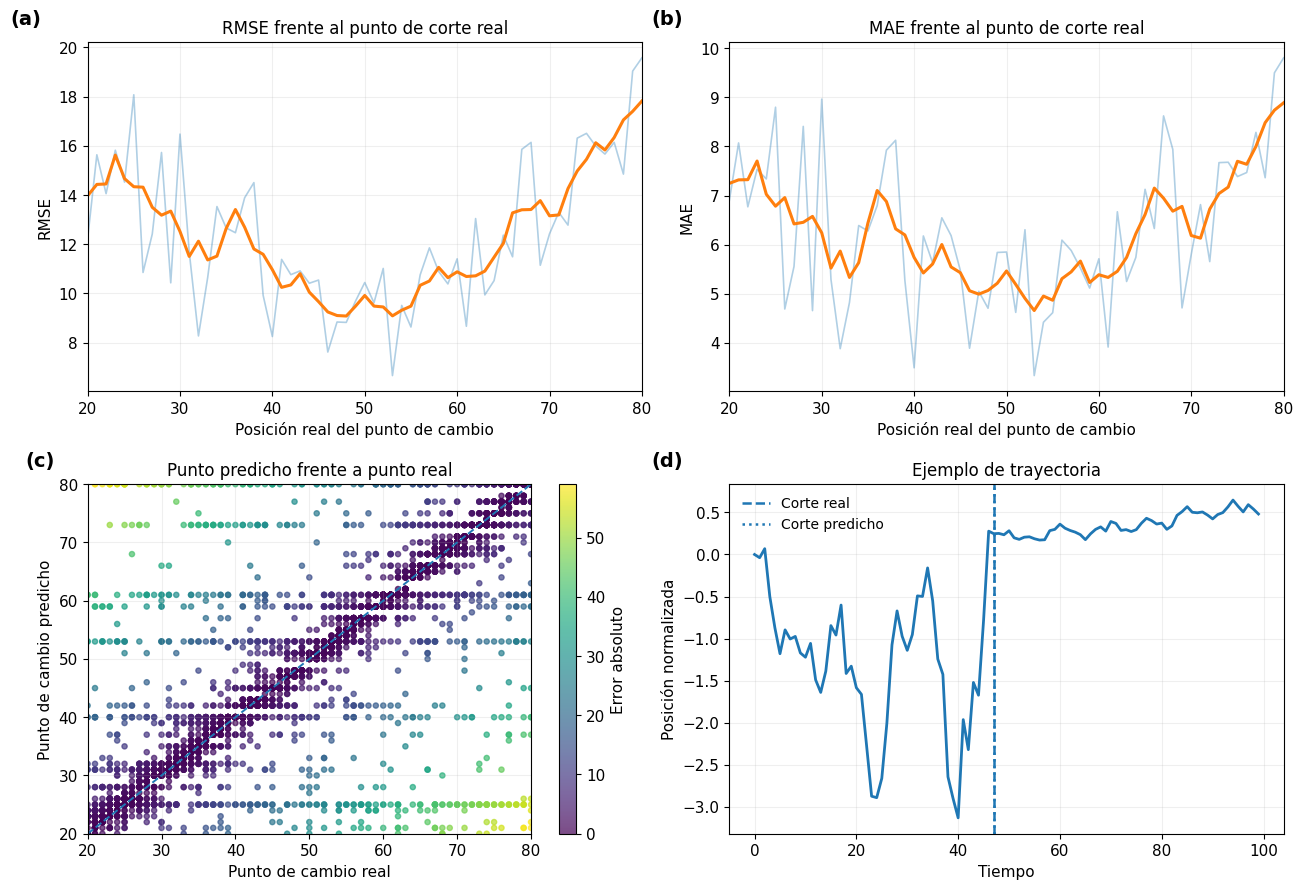

In [25]:
import numpy as np
import matplotlib.pyplot as plt

true_cuts = results_val["true_cuts"]
pred_cuts = results_val["pred_cuts"]
abs_errors = results_val["abs_errors"]

valid_positions = np.arange(CFG.min_seg_len, CFG.seq_len - CFG.min_seg_len + 1)

rmse_by_cut = []
mae_by_cut = []

for k in valid_positions:
    mask = (true_cuts == k)
    if np.sum(mask) > 0:
        errors = pred_cuts[mask] - true_cuts[mask]
        rmse_by_cut.append(np.sqrt(np.mean(errors**2)))
        mae_by_cut.append(np.mean(np.abs(errors)))
    else:
        rmse_by_cut.append(np.nan)
        mae_by_cut.append(np.nan)

rmse_by_cut = np.array(rmse_by_cut, dtype=float)
mae_by_cut = np.array(mae_by_cut, dtype=float)

def smooth_curve(y, window=5):
    y = np.asarray(y, dtype=float)
    out = np.copy(y)

    for i in range(len(y)):
        left = max(0, i - window // 2)
        right = min(len(y), i + window // 2 + 1)
        vals = y[left:right]
        vals = vals[~np.isnan(vals)]
        if len(vals) > 0:
            out[i] = np.mean(vals)
        else:
            out[i] = np.nan
    return out

rmse_smooth = smooth_curve(rmse_by_cut, window=5)
mae_smooth = smooth_curve(mae_by_cut, window=5)

example = sorted(results_val["examples"], key=lambda z: z["abs_error"])[0]
x_ex = example["x"]
true_cut_ex = example["true_cut"]
pred_cut_ex = example["pred_cut"]
t = np.arange(len(x_ex))

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11
})

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.subplots_adjust(wspace=0.30, hspace=0.32)

# (a) RMSE
ax = axes[0, 0]
ax.plot(valid_positions, rmse_by_cut, linewidth=1.2, alpha=0.35)
ax.plot(valid_positions, rmse_smooth, linewidth=2.2)
ax.set_title("RMSE frente al punto de corte real")
ax.set_xlabel("Posición real del punto de cambio")
ax.set_ylabel("RMSE")
ax.set_xlim(valid_positions.min(), valid_positions.max())
ax.grid(alpha=0.2)
ax.text(-0.14, 1.05, "(a)", transform=ax.transAxes, fontsize=14, fontweight="bold")

# (b) MAE
ax = axes[0, 1]
ax.plot(valid_positions, mae_by_cut, linewidth=1.2, alpha=0.35)
ax.plot(valid_positions, mae_smooth, linewidth=2.2)
ax.set_title("MAE frente al punto de corte real")
ax.set_xlabel("Posición real del punto de cambio")
ax.set_ylabel("MAE")
ax.set_xlim(valid_positions.min(), valid_positions.max())
ax.grid(alpha=0.2)
ax.text(-0.14, 1.05, "(b)", transform=ax.transAxes, fontsize=14, fontweight="bold")

# (c) Predicción frente a valor real
ax = axes[1, 0]
sc = ax.scatter(
    true_cuts,
    pred_cuts,
    c=abs_errors,
    s=14,
    alpha=0.7
)
ax.plot(
    [valid_positions.min(), valid_positions.max()],
    [valid_positions.min(), valid_positions.max()],
    linestyle="--",
    linewidth=1.4
)
ax.set_title("Punto predicho frente a punto real")
ax.set_xlabel("Punto de cambio real")
ax.set_ylabel("Punto de cambio predicho")
ax.set_xlim(valid_positions.min(), valid_positions.max())
ax.set_ylim(valid_positions.min(), valid_positions.max())
ax.grid(alpha=0.2)
ax.text(-0.14, 1.05, "(c)", transform=ax.transAxes, fontsize=14, fontweight="bold")

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Error absoluto")

# (d) Ejemplo de trayectoria
ax = axes[1, 1]
ax.plot(t, x_ex, linewidth=2.0)
ax.axvline(true_cut_ex, linestyle="--", linewidth=1.8, label="Corte real")
ax.axvline(pred_cut_ex, linestyle=":", linewidth=1.8, label="Corte predicho")
ax.set_title("Ejemplo de trayectoria")
ax.set_xlabel("Tiempo")
ax.set_ylabel("Posición normalizada")
ax.legend(frameon=False, fontsize=10)
ax.grid(alpha=0.2)
ax.text(-0.14, 1.05, "(d)", transform=ax.transAxes, fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

La figura presentada permite analizar el comportamiento del modelo desde varias perspectivas complementarias. En los paneles (a) y (b) se muestra la evolución del error de localización en función de la posición real del punto de cambio, utilizando respectivamente las métricas RMSE y MAE. En ambos casos se observa una tendencia similar: el error tiende a ser menor en la región central de la trayectoria y aumenta hacia los extremos. Este resultado sugiere que la detección del punto de cambio es más estable cuando los dos segmentos disponen de una longitud suficientemente equilibrada, ya que en esa situación el modelo dispone de más información útil para distinguir el cambio de régimen.

El panel (c) refuerza esta interpretación al representar la relación entre el punto de cambio real y el punto de cambio predicho. La mayor parte de las observaciones se concentra en torno a la diagonal, lo que indica una concordancia razonable entre los valores verdaderos y las estimaciones producidas por el modelo. Además, la escala de color asociada al error absoluto muestra que las discrepancias más pequeñas se acumulan cerca de dicha diagonal, mientras que los errores más elevados aparecen en predicciones alejadas de la correspondencia ideal.

Por su parte, el panel (d) presenta un ejemplo individual de trayectoria, junto con la localización real y estimada del punto de cambio. En este caso, ambas posiciones permanecen próximas, lo que proporciona una ilustración visual directa del funcionamiento del modelo sobre una muestra concreta. En conjunto, la figura confirma lo observado en las métricas de entrenamiento y validación: el modelo ha aprendido una representación informativa de la trayectoria y es capaz de localizar el punto de cambio con una precisión razonable dentro del marco considerado. Este comportamiento es coherente con el mejor resultado obtenido en validación, correspondiente a un MAE cercano a 6.29.

## Inferencia sobre nuevas trayectorias

Tras completar el entrenamiento, se recupera el modelo seleccionado según su rendimiento sobre el conjunto de validación. Dicho modelo se aplica posteriormente a trayectorias no vistas, con el fin de estimar la posición del punto de cambio.

In [18]:
def prepare_single_trajectory(x: np.ndarray) -> torch.Tensor:
    if len(x) != CFG.seq_len:
        raise ValueError(f"La trayectoria debe tener longitud {CFG.seq_len}")

    x = normalize_trajectory(np.asarray(x, dtype=np.float32))
    feats = build_features(x)

    return torch.tensor(feats, dtype=torch.float32).unsqueeze(0)


@torch.no_grad()
def predict_cut(model: nn.Module, x: np.ndarray, device: str):
    model.eval()

    x_tensor = prepare_single_trajectory(x).to(device)
    logits = model(x_tensor)
    probs = F.softmax(logits, dim=1).cpu().numpy()[0]

    pred_class = int(np.argmax(probs))
    pred_cut = class_to_cut(pred_class, min_seg_len=CFG.min_seg_len)

    return pred_class, pred_cut, probs

In [21]:
best_model = CutPointNet(
    in_channels=3,
    conv_channels=CFG.conv_channels,
    hidden_size=CFG.hidden_size,
    num_classes=CFG.num_classes,
    dropout=CFG.dropout,
).to(CFG.device)

best_model.load_state_dict(torch.load(CFG.model_path, map_location=CFG.device))
best_model.eval()

x_example, y_cls_example, y_cut_example = val_dataset[0]

pred_class, pred_cut, probs = predict_cut(best_model, x_example[:, 0].numpy(), CFG.device)

print("Corte real:", int(y_cut_example))
print("Corte predicho:", pred_cut)
print("Clase predicha:", pred_class)
print("Probabilidad máxima:", float(probs[pred_class]))

Corte real: 49
Corte predicho: 48
Clase predicha: 28
Probabilidad máxima: 0.22894719243049622


## Comentario sobre un ejemplo de inferencia

En el ejemplo evaluado tras el entrenamiento, el punto de corte real era $49$, mientras que la predicción del modelo fue $48$. Esto supone un error absoluto de solo $1$ posición, lo que ilustra que, incluso cuando no se produce coincidencia exacta de clase, la localización obtenida puede ser muy próxima al changepoint verdadero. Además, la probabilidad máxima asociada a la clase predicha fue aproximadamente $0.229$, lo que indica que el modelo asignó una confianza moderada a esta estimación. En conjunto, este tipo de resultado confirma que métricas como el MAE y el RMSE resultan especialmente adecuadas para valorar el rendimiento del modelo en este problema, ya que permiten reflejar la calidad de la localización incluso cuando la predicción no coincide exactamente con la etiqueta de referencia.

## Conclusión final

En este trabajo se ha estudiado el problema de localización de un único punto de cambio en trayectorias formadas por dos regímenes dinámicos distintos. Para ello, se ha adoptado una formulación discreta del problema, se ha generado un conjunto de datos sintético a partir de `andi_datasets` y se ha desarrollado una arquitectura neuronal híbrida, combinando capas convolucionales unidimensionales con una unidad recurrente bidireccional.

Los resultados obtenidos indican que el modelo es capaz de extraer información relevante de la trayectoria y de estimar la posición del changepoint con un nivel de precisión satisfactorio dentro del marco considerado. En particular, el mejor resultado en validación, con un MAE próximo a 6.29, sugiere que la estrategia propuesta resulta adecuada para abordar esta tarea, especialmente si se tiene en cuenta la dificultad intrínseca del problema y el número de posiciones admisibles del punto de corte.

Más allá del resultado cuantitativo, este trabajo ha permitido construir un procedimiento completo, coherente y reproducible, que integra formulación matemática, generación de datos, modelización y análisis de resultados. En este sentido, la metodología desarrollada no debe entenderse únicamente como una solución cerrada, sino también como una base de trabajo útil para futuras extensiones. Entre ellas, cabe señalar la generalización a trayectorias bidimensionales y tridimensionales, la consideración de múltiples puntos de cambio y la incorporación de tareas adicionales de caracterización de los segmentos.

En consecuencia, este estudio constituye un primer paso metodológicamente consistente dentro de una línea de investigación más amplia. A partir de los resultados obtenidos, se considera que el enfoque propuesto ofrece una base razonable para continuar profundizando en el análisis computacional de trayectorias con cambio de régimen y en el diseño de modelos más robustos para problemas de segmentación en difusión anómala.